<a href="https://colab.research.google.com/github/an-lale/UOC---Visualizacion/blob/main/Spiral_Plot.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Month,Price
0,1997-01,3.45
1,1997-02,2.15
2,1997-03,1.89
3,1997-04,2.03
4,1997-05,2.25


Tipos de datos:
 Month     object
Price    float64
dtype: object

Valores nulos:
 Month    0
Price    0
dtype: int64
Tipos de datos:
 Month    datetime64[ns]
Price           float64
dtype: object


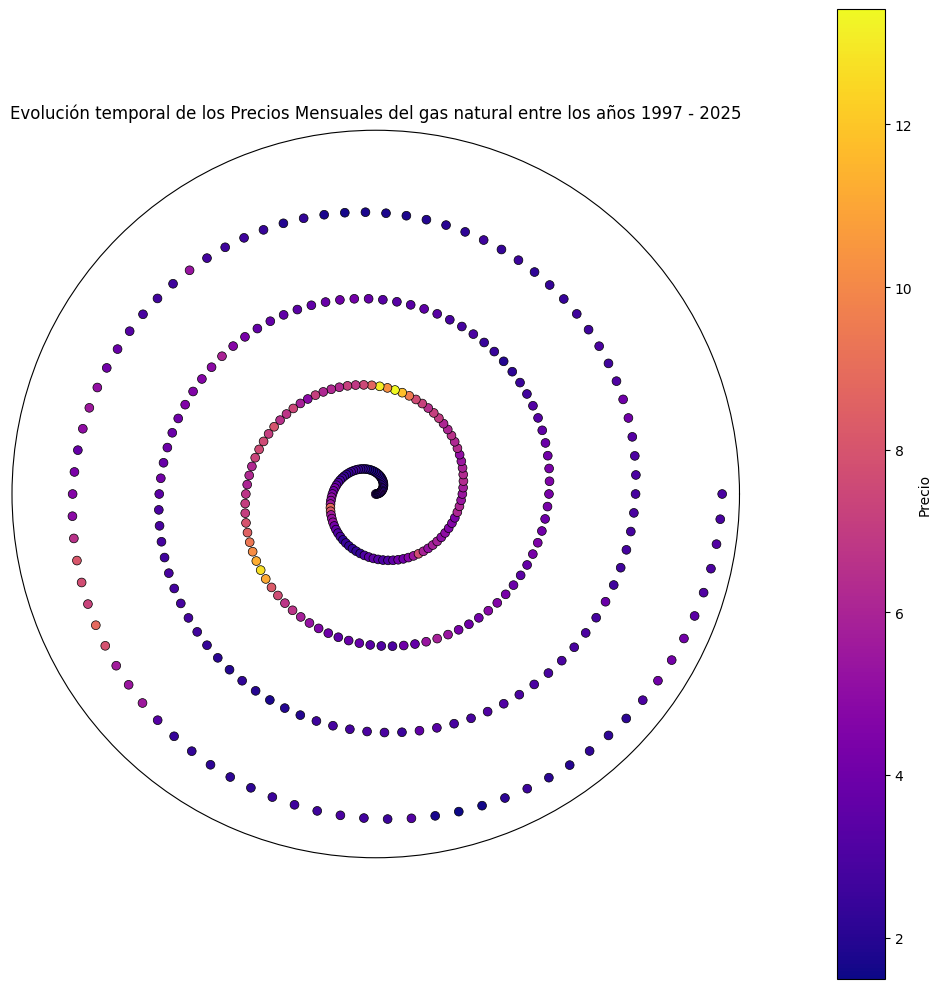

[https://datahub.io/core/natural-gas](https://datahub.io/core/natural-gas)

In [ ]:
# . Conectar con Google Drive
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

file_path = '/content/drive/MyDrive/Colab Notebooks/pec2_visualizacion/flat_ui_data_Sat Oct 25 2025.csv'
df = pd.read_csv(file_path)

# Mostramos las primeras filas del DataFrame
display(df.head())

# comprobamos el tipo de datos y si existen nulos
print("Tipos de datos:\n", df.dtypes)
print("\nValores nulos:\n", df.isnull().sum())

# Hay que ajustar el campo de fecha
df['Month'] = pd.to_datetime(df['Month'])
df = df.sort_values('Month').reset_index(drop=True)
print("Tipos de datos:\n",df.dtypes)

#construimos una espiral para evaluar la evolución temporal de los precios
# es una espiral de Arquímedes, y necesitamos seguir los siguientes pasos:
# el array de ángulos que se corresponderán con las posiciones de nuestros datos, en función de ellos nos dará el número
# de vueltas de la espiral
n = len(df)
angulo= np.linspace(0, 8 * np.pi, n)  # Espiral con varias vueltas

# tenemos que aplicar la fórmula de Arquímedes: r = a +b.angulo en coordenada polares
# donde tenemos que fijar los valores de a y b
# a es el centro de la espiral y b es la separación entre vueltas por lo que su valor deberá ser >0
a = 0.0 #centramos la espiral en 0
b = 0.2
r = a + b * angulo
precio = df['Price'].values

# Dibujamos la espiral con las coordendas polares
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, polar=True)

sc = ax.scatter(
    angulo,
    r,
    c=precio,
    cmap='plasma', #paleta de colores
    s=40,
    edgecolors='k',
    linewidth=0.5
)

# Generamos una paleta que ayuda a interpretar los colores de la espiral en función de los precios
cbar = plt.colorbar(sc, ax=ax, orientation='vertical', pad=0.1)
cbar.set_label('Precio')

ax.set_title("Evolución temporal de los Precios Mensuales del gas natural entre los años 1997 - 2025", va='bottom')
ax.set_xticklabels([])
ax.set_yticklabels([])
ax.grid(False)

plt.tight_layout()
plt.show()

display(Markdown('[https://datahub.io/core/natural-gas](https://datahub.io/core/natural-gas)'))


Bibliografía:
https://www.datasource.ai/es/data-science-articles/una-guia-paso-a-paso-para-crear-visualizaciones-avanzadas-de-datos-de-python-con-seaborn-matplotlib